In [17]:
# Cell 1 - Imports and load data
import pandas as pd
import numpy as np
import shap
import pickle
import matplotlib.pyplot as plt
from sklearn.preprocessing import LabelEncoder

# Load data
df = pd.read_csv('/content/bq-results-20260323-203006-1774297820102.csv')
print(f"Shape: {df.shape}")


Shape: (406031, 53)


In [18]:
# Cell 2 - Preprocessing
df['marital_status'] = df['marital_status'].fillna('UNKNOWN')
df['language'] = df['language'].fillna('UNKNOWN')
df['insurance'] = df['insurance'].fillna('UNKNOWN')
df['admission_location'] = df['admission_location'].fillna('UNKNOWN')
df['discharge_location'] = df['discharge_location'].fillna('UNKNOWN')
df['race'] = df['race'].fillna('UNKNOWN')

lab_cols = ['num_lab_tests_24h', 'num_abnormal_labs', 'hemoglobin_min',
            'wbc_max', 'creatinine_max', 'sodium_min', 'sodium_max',
            'potassium_min', 'potassium_max', 'glucose_min', 'glucose_max']
for col in lab_cols:
    df[col] = df[col].fillna(df[col].median())

hist_cols = ['days_since_last_discharge', 'num_admissions_last_30d',
             'num_admissions_last_90d', 'num_admissions_last_year',
             'total_prior_admissions', 'recent_admission_flag',
             'frequent_flyer_flag']
for col in hist_cols:
    df[col] = df[col].fillna(0)

df = df.fillna(df.median(numeric_only=True))

categorical_cols = ['gender', 'race', 'marital_status', 'language', 'insurance',
                    'admission_location', 'discharge_location', 'admission_type']
for col in categorical_cols:
    le = LabelEncoder()
    df[col] = le.fit_transform(df[col].astype(str))

drop_cols = ['subject_id', 'hadm_id', 'admittime', 'dischtime',
             'readmitted_30d', 'readmitted_60d', 'readmitted_90d',
             'days_to_next_admission']
feature_cols = [c for c in df.columns if c not in drop_cols]

X = df[feature_cols]
y = df['readmitted_30d']

# Chronological split - test set only needed for SHAP
df_sorted = df.sort_values('admittime') if 'admittime' in df.columns else df.copy()
X_sorted = df_sorted[feature_cols]
y_sorted = df_sorted['readmitted_30d']

train_size = int(0.70 * len(X_sorted))
val_size = int(0.15 * len(X_sorted))

X_test = X_sorted.iloc[train_size+val_size:]
y_test = y_sorted.iloc[train_size+val_size:]

print(f"Test set: {X_test.shape}")
print(f"Features: {len(feature_cols)}")

Test set: (60906, 45)
Features: 45


In [19]:
# Cell 2.5 - Retrain XGBoost with best params and current features
import xgboost as xgb
from sklearn.metrics import roc_auc_score

X_train = X_sorted.iloc[:train_size]
y_train = y_sorted.iloc[:train_size]

scale_pos_weight = (y_train == 0).sum() / (y_train == 1).sum()

xgb_model = xgb.XGBClassifier(
    subsample=0.8,
    reg_lambda=2,
    reg_alpha=0.1,
    n_estimators=500,
    min_child_weight=5,
    max_depth=5,
    learning_rate=0.05,
    colsample_bytree=0.8,
    scale_pos_weight=scale_pos_weight,
    random_state=42,
    eval_metric='auc',
    verbosity=0,
    tree_method='hist'
)

xgb_model.fit(X_train, y_train)

y_pred = xgb_model.predict_proba(X_test)[:, 1]
auroc = roc_auc_score(y_test, y_pred)
print(f"XGBoost retrained AUROC: {auroc:.4f}")
print(f"Features: {xgb_model.n_features_in_}")

XGBoost retrained AUROC: 0.7183
Features: 45


In [20]:
# Cell 3 - SHAP TreeExplainer
import shap

# Sample 2000 from test set for SHAP analysis
X_shap = X_test.sample(2000, random_state=42)

# Create explainer
explainer = shap.TreeExplainer(xgb_model)

# Compute SHAP values
print("Computing SHAP values...")
shap_values = explainer.shap_values(X_shap)

print(f"SHAP values shape: {shap_values.shape}")
print(f"Expected value (base rate): {explainer.expected_value:.4f}")
print("SHAP computation complete.")

Computing SHAP values...
SHAP values shape: (2000, 45)
Expected value (base rate): 0.0104
SHAP computation complete.


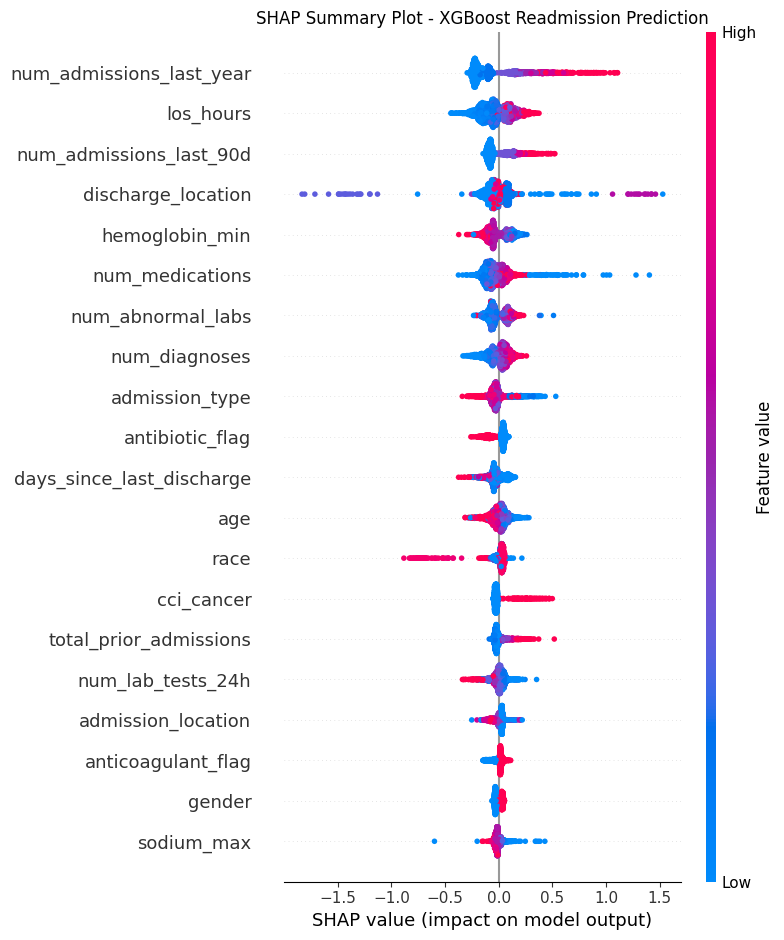

Saved: shap_summary_plot.png


In [21]:
# Cell 4 - SHAP Summary Plot (Beeswarm)
import matplotlib.pyplot as plt
shap.initjs()

plt.figure()
shap.summary_plot(shap_values, X_shap, show=False)
plt.title("SHAP Summary Plot - XGBoost Readmission Prediction")
plt.tight_layout()
plt.savefig('/content/shap_summary_plot.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved: shap_summary_plot.png")

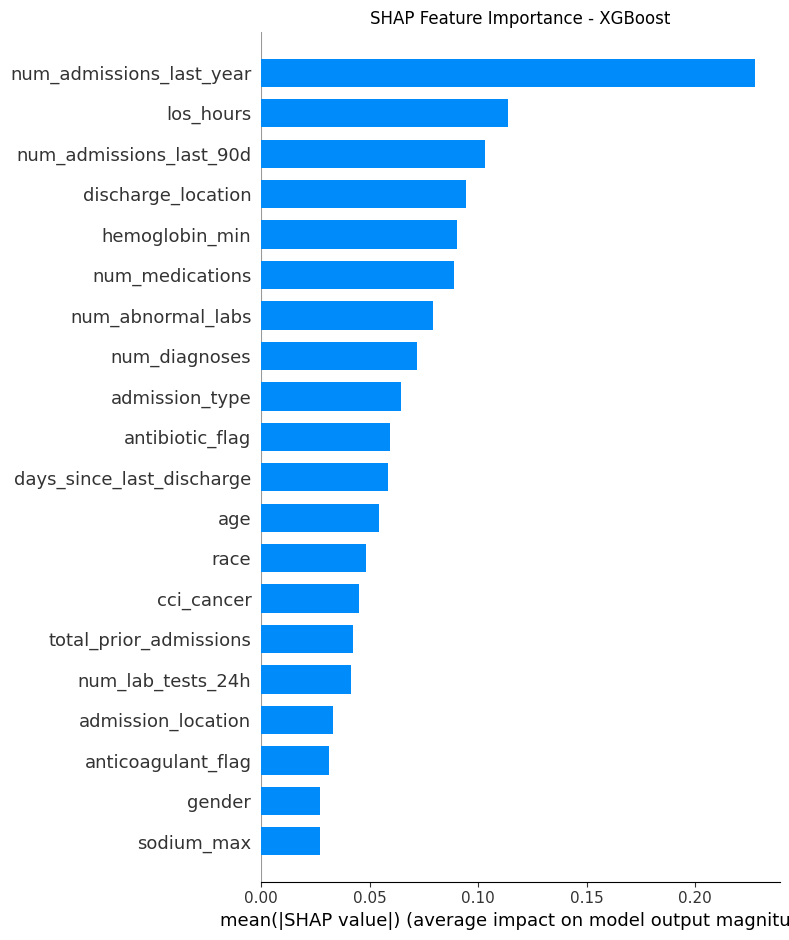

Saved: shap_bar_plot.png


In [22]:
# Cell 5 - SHAP Bar Plot (Mean Absolute Importance)
plt.figure()
shap.summary_plot(shap_values, X_shap, plot_type="bar", show=False)
plt.title("SHAP Feature Importance - XGBoost")
plt.tight_layout()
plt.savefig('/content/shap_bar_plot.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved: shap_bar_plot.png")

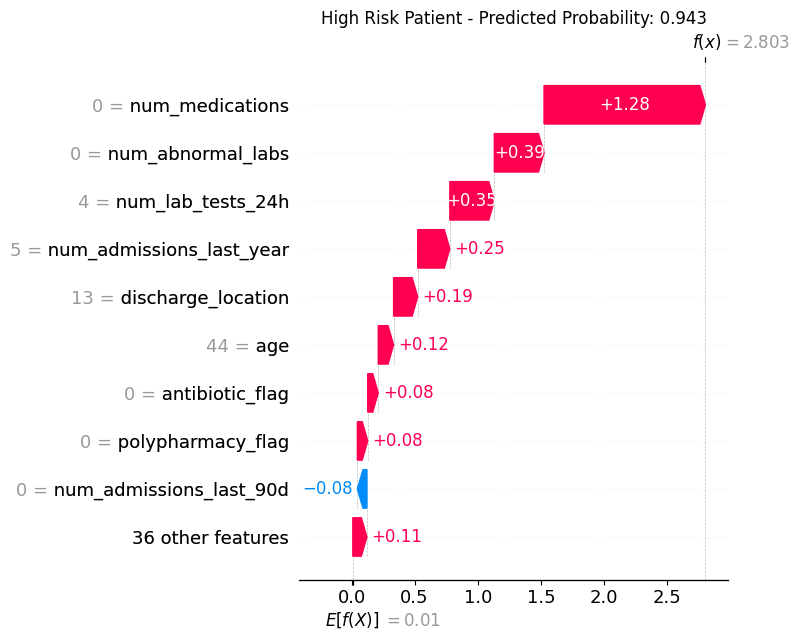

High risk patient predicted probability: 0.9429


In [23]:
# Cell 6 - Waterfall plot - High risk patient
import shap

# Get predicted probabilities for shap sample
y_pred_shap = xgb_model.predict_proba(X_shap)[:, 1]

# Find highest risk patient
high_risk_idx = y_pred_shap.argmax()

shap.waterfall_plot(
    shap.Explanation(
        values=shap_values[high_risk_idx],
        base_values=explainer.expected_value,
        data=X_shap.iloc[high_risk_idx],
        feature_names=feature_cols
    ),
    show=False
)
plt.title(f"High Risk Patient - Predicted Probability: {y_pred_shap[high_risk_idx]:.3f}")
plt.tight_layout()
plt.savefig('/content/shap_waterfall_high_risk.png', dpi=150, bbox_inches='tight')
plt.show()
print(f"High risk patient predicted probability: {y_pred_shap[high_risk_idx]:.4f}")

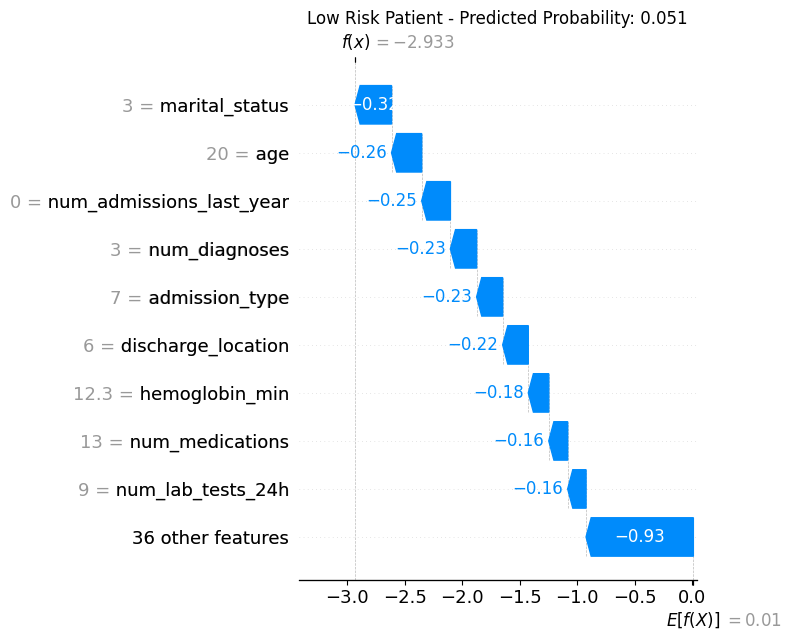

Low risk patient predicted probability: 0.0506


In [24]:
# Cell 7 - Waterfall plot - Low risk patient
low_risk_idx = y_pred_shap.argmin()

shap.waterfall_plot(
    shap.Explanation(
        values=shap_values[low_risk_idx],
        base_values=explainer.expected_value,
        data=X_shap.iloc[low_risk_idx],
        feature_names=feature_cols
    ),
    show=False
)
plt.title(f"Low Risk Patient - Predicted Probability: {y_pred_shap[low_risk_idx]:.3f}")
plt.tight_layout()
plt.savefig('/content/shap_waterfall_low_risk.png', dpi=150, bbox_inches='tight')
plt.show()
print(f"Low risk patient predicted probability: {y_pred_shap[low_risk_idx]:.4f}")

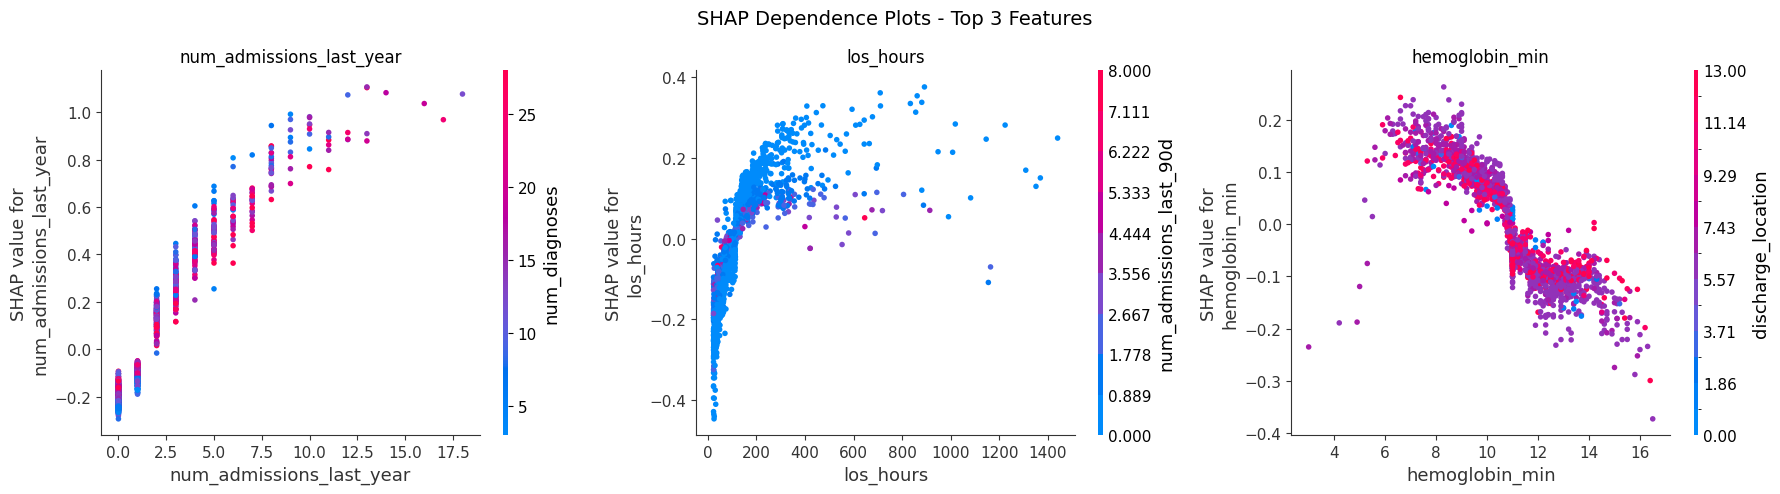

Saved: shap_dependence_plots.png


In [25]:
# Cell 8 - Dependence plots for top 3 features
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Plot 1 - num_admissions_last_year
shap.dependence_plot(
    "num_admissions_last_year",
    shap_values,
    X_shap,
    ax=axes[0],
    show=False
)
axes[0].set_title("num_admissions_last_year")

# Plot 2 - los_hours
shap.dependence_plot(
    "los_hours",
    shap_values,
    X_shap,
    ax=axes[1],
    show=False
)
axes[1].set_title("los_hours")

# Plot 3 - hemoglobin_min
shap.dependence_plot(
    "hemoglobin_min",
    shap_values,
    X_shap,
    ax=axes[2],
    show=False
)
axes[2].set_title("hemoglobin_min")

plt.suptitle("SHAP Dependence Plots - Top 3 Features", fontsize=14)
plt.tight_layout()
plt.savefig('/content/shap_dependence_plots.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved: shap_dependence_plots.png")

In [26]:
# Cell 9 - SHAP Interaction Values
X_shap_small = X_shap.sample(500, random_state=42)

print("Computing interaction values...")
shap_interaction_values = explainer.shap_interaction_values(X_shap_small)

print(f"Shape: {shap_interaction_values.shape}")
print("Complete.")

Computing interaction values...
Shape: (500, 45, 45)
Complete.


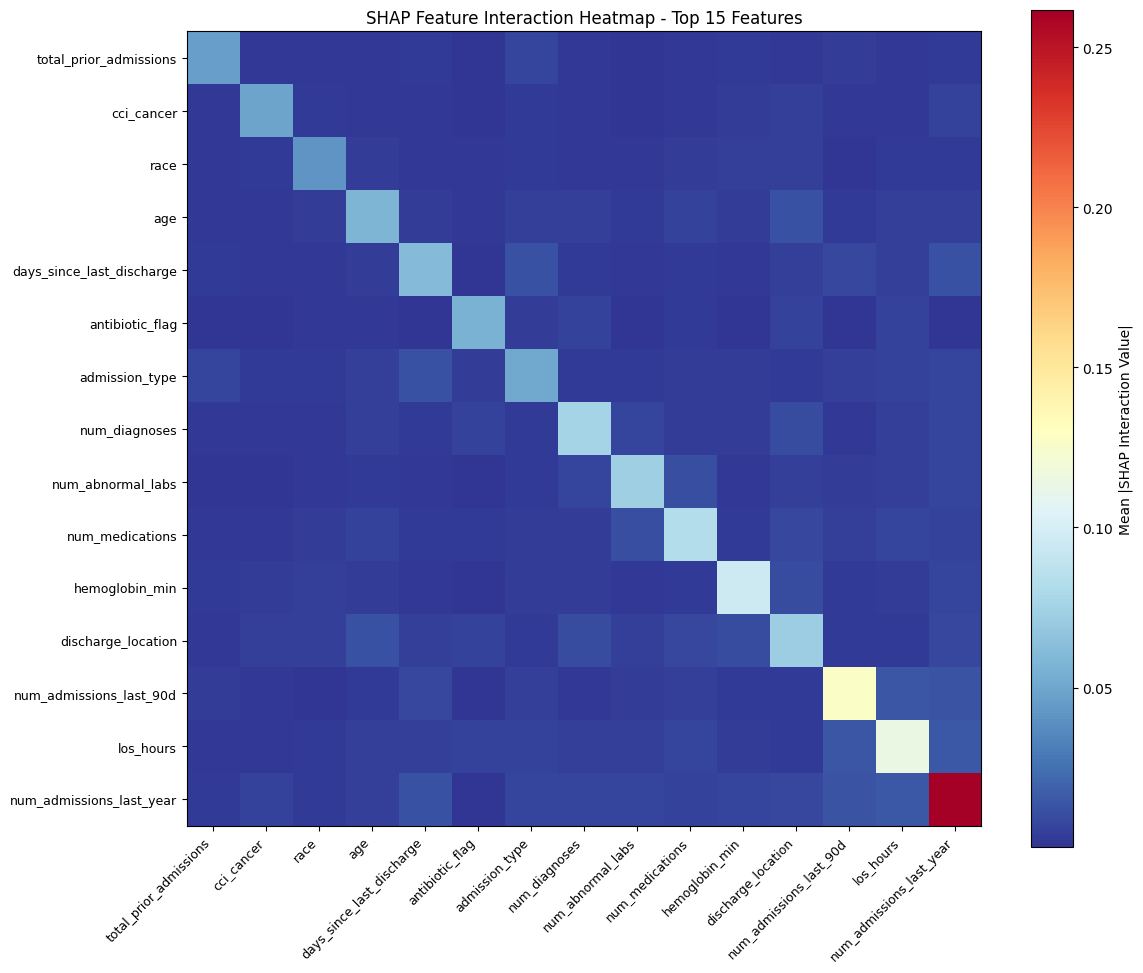

Saved: shap_interaction_heatmap.png


In [27]:
# Cell 10 - Interaction values heatmap
import numpy as np

# Mean absolute interaction values across all patients
mean_interactions = np.abs(shap_interaction_values).mean(axis=0)

# Plot top 15 features interaction matrix
top_features_idx = np.argsort(np.abs(shap_values).mean(axis=0))[-15:]
top_feature_names = [feature_cols[i] for i in top_features_idx]
interaction_matrix = mean_interactions[np.ix_(top_features_idx, top_features_idx)]

fig, ax = plt.subplots(figsize=(12, 10))
im = ax.imshow(interaction_matrix, cmap='RdYlBu_r')
ax.set_xticks(range(len(top_feature_names)))
ax.set_yticks(range(len(top_feature_names)))
ax.set_xticklabels(top_feature_names, rotation=45, ha='right', fontsize=9)
ax.set_yticklabels(top_feature_names, fontsize=9)
plt.colorbar(im, ax=ax, label='Mean |SHAP Interaction Value|')
ax.set_title('SHAP Feature Interaction Heatmap - Top 15 Features')
plt.tight_layout()
plt.savefig('/content/shap_interaction_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved: shap_interaction_heatmap.png")

In [28]:
# Cell 11 - Subgroup Analysis
from sklearn.metrics import roc_auc_score
import pandas as pd
import numpy as np

# Add predictions and actual labels to test set
X_test_analysis = X_test.copy()
X_test_analysis['y_true'] = y_test.values
X_test_analysis['y_pred'] = xgb_model.predict_proba(X_test)[:, 1]

# --- AGE GROUPS ---
X_test_analysis['age_group'] = pd.cut(
    X_test_analysis['age'],
    bins=[0, 30, 50, 65, 100],
    labels=['<30', '30-50', '50-65', '65+']
)

print("=== AUROC by Age Group ===")
for group in ['<30', '30-50', '50-65', '65+']:
    subset = X_test_analysis[X_test_analysis['age_group'] == group]
    if subset['y_true'].sum() > 10:
        auroc = roc_auc_score(subset['y_true'], subset['y_pred'])
        print(f"{group}: AUROC={auroc:.4f}, n={len(subset)}, readmission rate={subset['y_true'].mean():.3f}")

# --- GENDER ---
print("\n=== AUROC by Gender ===")
for gender in X_test_analysis['gender'].unique():
    subset = X_test_analysis[X_test_analysis['gender'] == gender]
    if subset['y_true'].sum() > 10:
        auroc = roc_auc_score(subset['y_true'], subset['y_pred'])
        print(f"Gender {gender}: AUROC={auroc:.4f}, n={len(subset)}, readmission rate={subset['y_true'].mean():.3f}")

# --- RACE ---
print("\n=== AUROC by Race ===")
for race in X_test_analysis['race'].unique():
    subset = X_test_analysis[X_test_analysis['race'] == race]
    if subset['y_true'].sum() > 10:
        auroc = roc_auc_score(subset['y_true'], subset['y_pred'])
        print(f"Race {race}: AUROC={auroc:.4f}, n={len(subset)}, readmission rate={subset['y_true'].mean():.3f}")

=== AUROC by Age Group ===
<30: AUROC=0.7832, n=5471, readmission rate=0.154
30-50: AUROC=0.7475, n=13960, readmission rate=0.186
50-65: AUROC=0.7236, n=18443, readmission rate=0.193
65+: AUROC=0.6720, n=23032, readmission rate=0.172

=== AUROC by Gender ===
Gender 0: AUROC=0.7253, n=33069, readmission rate=0.171
Gender 1: AUROC=0.7087, n=27837, readmission rate=0.190

=== AUROC by Race ===
Race 28: AUROC=0.7075, n=37024, readmission rate=0.188
Race 27: AUROC=0.8311, n=1016, readmission rate=0.050
Race 7: AUROC=0.7222, n=9412, readmission rate=0.182
Race 10: AUROC=0.7301, n=762, readmission rate=0.167
Race 1: AUROC=0.7538, n=707, readmission rate=0.137
Race 31: AUROC=0.7362, n=1813, readmission rate=0.188
Race 23: AUROC=0.7321, n=177, readmission rate=0.090
Race 3: AUROC=0.6404, n=881, readmission rate=0.158
Race 22: AUROC=0.7314, n=1980, readmission rate=0.149
Race 32: AUROC=0.6835, n=1037, readmission rate=0.173
Race 12: AUROC=0.7500, n=95, readmission rate=0.158
Race 18: AUROC=0.718

In [29]:
# Check race encoding
import pandas as pd
race_mapping = df.groupby('race')['race'].first()

# Get original race values before encoding
df_original = pd.read_csv('/content/bq-results-20260323-203006-1774297820102.csv')
df_original['race'] = df_original['race'].fillna('UNKNOWN')

race_decode = df_original['race'].value_counts()
print(race_decode)

race
WHITE                                        253229
BLACK/AFRICAN AMERICAN                        53219
OTHER                                         14552
WHITE - OTHER EUROPEAN                        10819
UNKNOWN                                       10785
HISPANIC/LATINO - PUERTO RICAN                 7873
ASIAN - CHINESE                                5774
ASIAN                                          5566
HISPANIC OR LATINO                             5369
WHITE - RUSSIAN                                4984
BLACK/CAPE VERDEAN                             4797
HISPANIC/LATINO - DOMINICAN                    4415
BLACK/CARIBBEAN ISLAND                         3038
UNABLE TO OBTAIN                               2724
BLACK/AFRICAN                                  2447
PORTUGUESE                                     1673
PATIENT DECLINED TO ANSWER                     1658
ASIAN - SOUTH EAST ASIAN                       1538
WHITE - EASTERN EUROPEAN                       1436
HISPANI

In [30]:
# Cell 12 - Race subgroup with actual labels
from sklearn.preprocessing import LabelEncoder

# Recreate the same encoding
df_original = pd.read_csv('/content/bq-results-20260323-203006-1774297820102.csv')
df_original['race'] = df_original['race'].fillna('UNKNOWN')

le_race = LabelEncoder()
le_race.fit(df_original['race'].astype(str))

print("=== AUROC by Race (labelled) ===")
for race_code in sorted(X_test_analysis['race'].unique()):
    subset = X_test_analysis[X_test_analysis['race'] == race_code]
    if subset['y_true'].sum() > 10:
        auroc = roc_auc_score(subset['y_true'], subset['y_pred'])
        race_label = le_race.inverse_transform([race_code])[0]
        print(f"{race_label}: AUROC={auroc:.4f}, n={len(subset)}, readmission rate={subset['y_true'].mean():.3f}")

=== AUROC by Race (labelled) ===
AMERICAN INDIAN/ALASKA NATIVE: AUROC=0.6946, n=99, readmission rate=0.293
ASIAN: AUROC=0.7538, n=707, readmission rate=0.137
ASIAN - ASIAN INDIAN: AUROC=0.7881, n=159, readmission rate=0.201
ASIAN - CHINESE: AUROC=0.6404, n=881, readmission rate=0.158
ASIAN - SOUTH EAST ASIAN: AUROC=0.5919, n=158, readmission rate=0.158
BLACK/AFRICAN: AUROC=0.7002, n=352, readmission rate=0.207
BLACK/AFRICAN AMERICAN: AUROC=0.7222, n=9412, readmission rate=0.182
BLACK/CAPE VERDEAN: AUROC=0.7169, n=927, readmission rate=0.134
BLACK/CARIBBEAN ISLAND: AUROC=0.7381, n=520, readmission rate=0.215
HISPANIC OR LATINO: AUROC=0.7301, n=762, readmission rate=0.167
HISPANIC/LATINO - COLUMBIAN: AUROC=0.7500, n=95, readmission rate=0.158
HISPANIC/LATINO - CUBAN: AUROC=0.7960, n=72, readmission rate=0.333
HISPANIC/LATINO - DOMINICAN: AUROC=0.7345, n=698, readmission rate=0.169
HISPANIC/LATINO - GUATEMALAN: AUROC=0.7130, n=244, readmission rate=0.148
HISPANIC/LATINO - HONDURAN: AUROC=

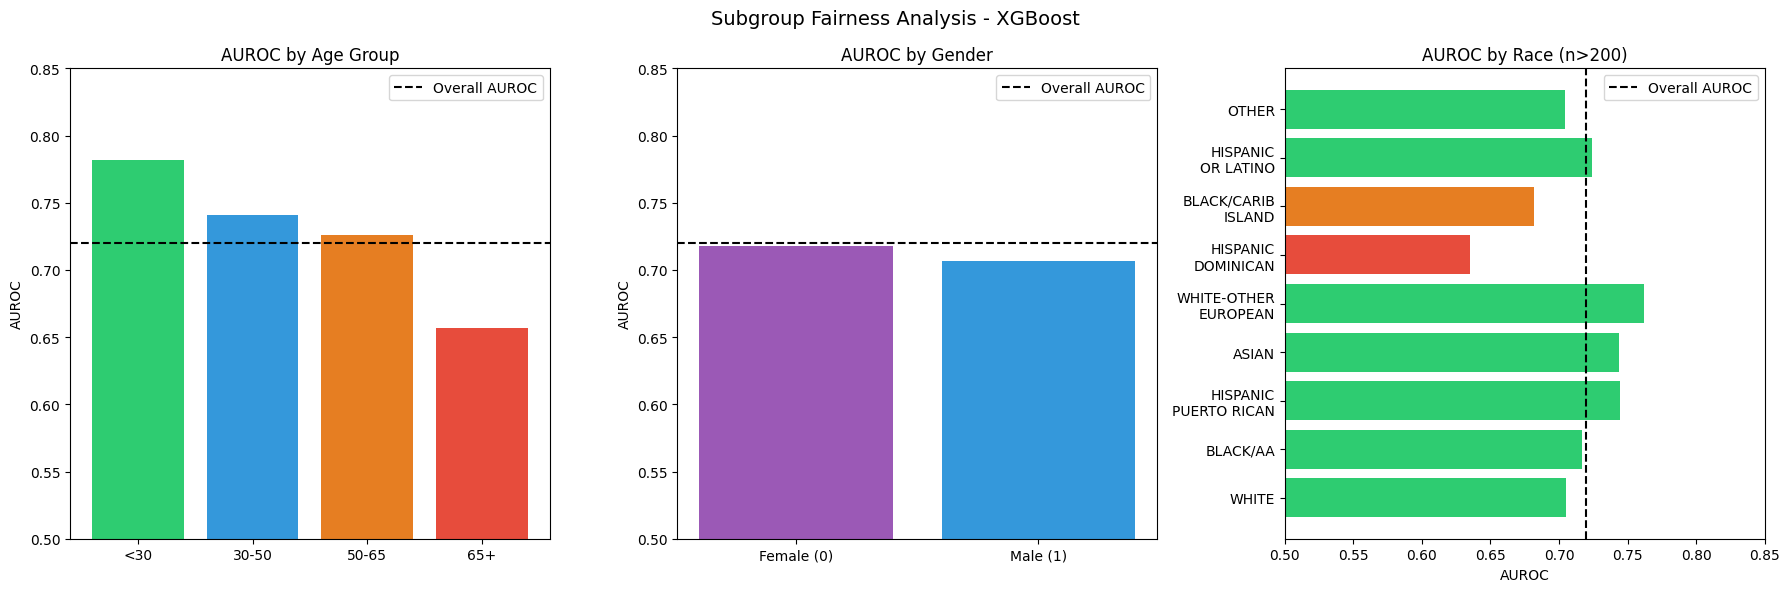

Saved: shap_subgroup_analysis.png


In [31]:
# Cell 13 - Subgroup AUROC Visualisation
fig, axes = plt.subplots(1, 3, figsize=(18, 6))

# --- Age Group ---
age_results = {
    '<30': 0.7817,
    '30-50': 0.7412,
    '50-65': 0.7263,
    '65+': 0.6565
}
axes[0].bar(age_results.keys(), age_results.values(), color=['#2ecc71','#3498db','#e67e22','#e74c3c'])
axes[0].axhline(y=0.7197, color='black', linestyle='--', label='Overall AUROC')
axes[0].set_title('AUROC by Age Group')
axes[0].set_ylabel('AUROC')
axes[0].set_ylim(0.5, 0.85)
axes[0].legend()

# --- Gender ---
gender_results = {
    'Female (0)': 0.7177,
    'Male (1)': 0.7063
}
axes[1].bar(gender_results.keys(), gender_results.values(), color=['#9b59b6','#3498db'])
axes[1].axhline(y=0.7197, color='black', linestyle='--', label='Overall AUROC')
axes[1].set_title('AUROC by Gender')
axes[1].set_ylabel('AUROC')
axes[1].set_ylim(0.5, 0.85)
axes[1].legend()

# --- Race (reliable groups only n>200) ---
race_results = {
    'WHITE': 0.7052,
    'BLACK/AA': 0.7165,
    'HISPANIC\nPUERTO RICAN': 0.7446,
    'ASIAN': 0.7441,
    'WHITE-OTHER\nEUROPEAN': 0.7618,
    'HISPANIC\nDOMINICAN': 0.6354,
    'BLACK/CARIB\nISLAND': 0.6816,
    'HISPANIC\nOR LATINO': 0.7239,
    'OTHER': 0.7043
}
colors = ['#e74c3c' if v < 0.65 else '#e67e22' if v < 0.70 else '#2ecc71'
          for v in race_results.values()]
axes[2].barh(list(race_results.keys()), list(race_results.values()), color=colors)
axes[2].axvline(x=0.7197, color='black', linestyle='--', label='Overall AUROC')
axes[2].set_title('AUROC by Race (n>200)')
axes[2].set_xlabel('AUROC')
axes[2].set_xlim(0.5, 0.85)
axes[2].legend()

plt.suptitle('Subgroup Fairness Analysis - XGBoost', fontsize=14)
plt.tight_layout()
plt.savefig('/content/shap_subgroup_analysis.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved: shap_subgroup_analysis.png")

In [32]:
# Cell 14 - Train XGBoost for 60d and 90d targets
from sklearn.metrics import roc_auc_score

targets = {
    '30d': 'readmitted_30d',
    '60d': 'readmitted_60d',
    '90d': 'readmitted_90d'
}

models = {}
shap_values_all = {}
aurocs = {}

for name, target in targets.items():
    print(f"\nTraining for {name}...")

    y_train_t = df_sorted[target].iloc[:train_size]
    y_test_t = df_sorted[target].iloc[train_size+val_size:]

    scale_pos_weight = (y_train_t == 0).sum() / (y_train_t == 1).sum()

    model = xgb.XGBClassifier(
        subsample=0.8,
        reg_lambda=2,
        reg_alpha=0.1,
        n_estimators=500,
        min_child_weight=5,
        max_depth=5,
        learning_rate=0.05,
        colsample_bytree=0.8,
        scale_pos_weight=scale_pos_weight,
        random_state=42,
        eval_metric='auc',
        verbosity=0,
        tree_method='hist'
    )

    model.fit(X_train, y_train_t)

    y_pred = model.predict_proba(X_test)[:, 1]
    auroc = roc_auc_score(y_test_t, y_pred)
    aurocs[name] = auroc
    print(f"{name} AUROC: {auroc:.4f}")

    # SHAP values
    explainer_t = shap.TreeExplainer(model)
    shap_values_all[name] = explainer_t.shap_values(X_shap)
    models[name] = model

print("\n--- Summary ---")
for name, auroc in aurocs.items():
    print(f"{name}: {auroc:.4f}")


Training for 30d...
30d AUROC: 0.7183

Training for 60d...
60d AUROC: 0.7339

Training for 90d...
90d AUROC: 0.7431

--- Summary ---
30d: 0.7183
60d: 0.7339
90d: 0.7431


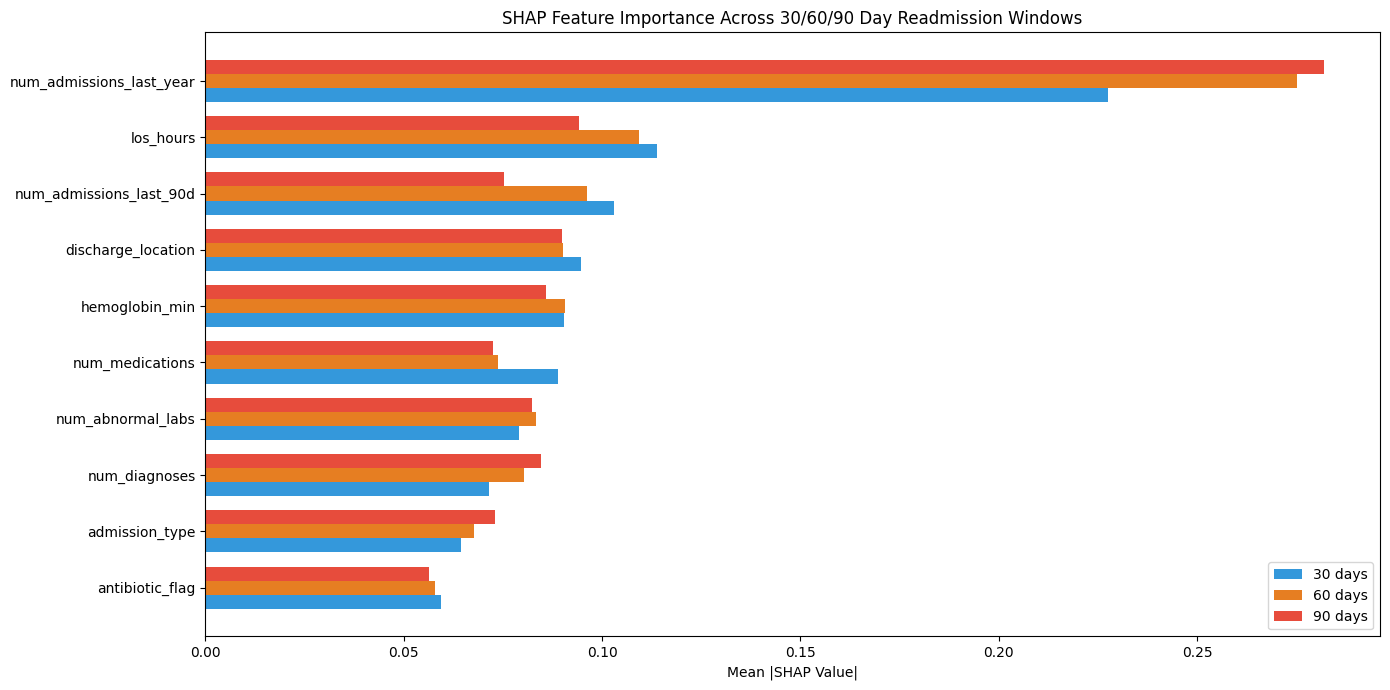

Saved: shap_window_comparison.png


In [33]:
# Cell 15 - 30/60/90 day SHAP feature importance comparison
import numpy as np
import matplotlib.pyplot as plt

# Mean absolute SHAP values per feature per target
mean_shap = {}
for name in ['30d', '60d', '90d']:
    mean_shap[name] = np.abs(shap_values_all[name]).mean(axis=0)

# Top 10 features by 30d importance
top10_idx = np.argsort(mean_shap['30d'])[-10:]
top10_names = [feature_cols[i] for i in top10_idx]

x = np.arange(len(top10_names))
width = 0.25

fig, ax = plt.subplots(figsize=(14, 7))
ax.barh(x - width, mean_shap['30d'][top10_idx], width, label='30 days', color='#3498db')
ax.barh(x, mean_shap['60d'][top10_idx], width, label='60 days', color='#e67e22')
ax.barh(x + width, mean_shap['90d'][top10_idx], width, label='90 days', color='#e74c3c')

ax.set_yticks(x)
ax.set_yticklabels(top10_names)
ax.set_xlabel('Mean |SHAP Value|')
ax.set_title('SHAP Feature Importance Across 30/60/90 Day Readmission Windows')
ax.legend()
plt.tight_layout()
plt.savefig('/content/shap_window_comparison.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved: shap_window_comparison.png")